In [40]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [41]:
df = pd.read_csv('height-weight.csv')

In [42]:
df.head()

,weight,height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


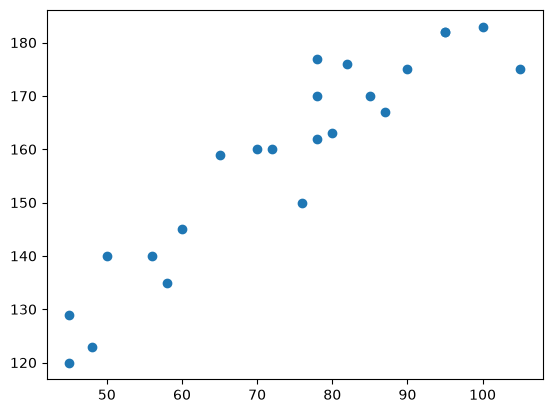

In [43]:
plt.scatter(df['weight'], df['height'])

In [44]:
df.corr()

,weight,height
weight,1.000000,0.931142
height,0.931142,1.000000


In [45]:
X = df[['weight']]
Y = df['height']

In [46]:
# train test split
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

In [47]:
X_train.shape

(17, 1)

In [48]:
# standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [49]:
# apply linear regression
from sklearn.linear_model import LinearRegression
regression = LinearRegression(n_jobs=-1)
regression.fit(X_train, Y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",-1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[17.3]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,156.5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[4.12]


In [50]:
print("Intercept:", regression.intercept_)
print("Coefficient:", regression.coef_)

Intercept: 156.47058823529412
Coefficient: [17.2982057]


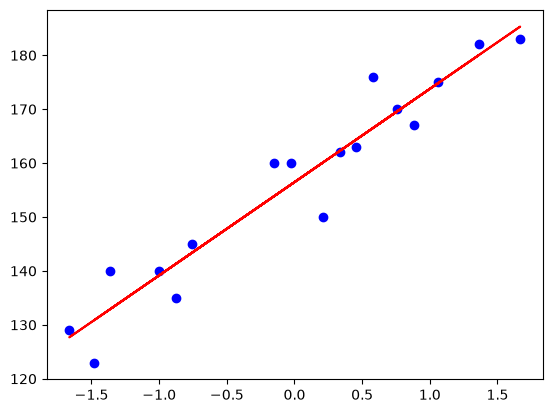

In [51]:
# plot the regression line
plt.scatter(X_train, Y_train, color='blue')
plt.plot(X_train, regression.predict(X_train), color='red')


In [52]:
#predicting for test data
Y_pred = regression.predict(X_test)
Y_pred

array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
       148.64197186, 190.55897293])

In [55]:
#performance metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
mse = mean_squared_error(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)
adjusted_r2 = 1 - (1-r2)*(len(Y_test)-1)/(len(Y_test)-X_test.shape[1]-1)
print("Mean Squared Error:", mse, "\nMean Absolute Error:", mae, "\nRoot Mean Squared Error:", rmse, "\nR-squared:", r2, "\nAdjusted R-squared:", adjusted_r2)

Mean Squared Error: 114.84069295228699 
Mean Absolute Error: 9.66512588679501 
Root Mean Squared Error: 10.716374991212605 
R-squared: 0.7360826717981276 
Adjusted R-squared: 0.6701033397476595


In [58]:
#OLS Regression
import statsmodels.api as sm
model = sm.OLS(Y_train, X_train).fit()
predictions = model.predict(X_test)
print(predictions)
print(model.summary())

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]
                                 OLS Regression Results                                
Dep. Variable:                 height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Tue, 21 Jul 2026   Prob (F-statistic):                       0.664
Time:                        06:46:35   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err       